In [16]:
import os
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
def compare_evaluation_results(rag_filename: str, baseline_filename: str):
    results = []
    for filename, label in [(rag_filename, 'RAG Agent'), (baseline_filename, 'Baseline')]:
        path = os.path.join("..", "assets", "evaluation_result", filename)
        with open(path, 'r') as f:
            data = json.load(f)
        
        temp_df = pd.DataFrame(data['detail'])
        temp_df['model'] = label 
        
        temp_df['is_correct_int'] = temp_df['is_correct'].fillna(0).astype(int)

        results.append(temp_df)

    df = pd.concat(results, ignore_index=True)

    sns.set_theme(style="whitegrid")
    plt.rcParams['figure.figsize'] = [14, 6]

    plt.figure()
    level_acc = df.groupby(['level', 'model'], as_index=False)['is_correct_int'].mean()
    
    ax1 = sns.barplot(data=level_acc, x='level', y='is_correct_int', hue='model', palette="viridis")
    plt.title('Accuracy Comparison by Level', fontsize=15)
    plt.ylabel('Accuracy')
    plt.ylim(0, 1.1)
    
    for p in ax1.patches:
        if not np.isnan(p.get_height()) and p.get_height() > 0.0: 
            ax1.annotate(f'{p.get_height():.2f}', 
                         (p.get_x() + p.get_width() / 2., p.get_height()), 
                         ha = 'center', va = 'center', 
                         xytext = (0, 9), 
                         textcoords = 'offset points')
    plt.show()

    plt.figure()
    type_acc = df.groupby(['type', 'model'], as_index=False)['is_correct_int'].mean()
    
    ax2 = sns.barplot(data=type_acc, x='type', y='is_correct_int', hue='model', palette="magma")
    plt.title('Accuracy Comparison by Question Type', fontsize=15)
    plt.xticks(rotation=45)
    plt.ylabel('Accuracy')
    plt.ylim(0, 1.1)
    
    for p in ax2.patches:
        if p.get_height() > 0:
            ax2.annotate(f'{p.get_height():.2f}', 
                         (p.get_x() + p.get_width() / 2., p.get_height()), 
                         ha = 'center', va = 'center', 
                         xytext = (0, 9), 
                         textcoords = 'offset points',
                         fontsize=9)
    plt.show()

    print("### Overall Performance Comparison ###")
    overall = df.groupby('model')['is_correct_int'].agg(['mean', 'count']).rename(columns={'mean': 'Accuracy', 'count': 'Total'})
    print(overall)
    
    rag_acc = overall.loc['RAG Agent', 'Accuracy']
    base_acc = overall.loc['Baseline', 'Accuracy']
    improvement = (rag_acc - base_acc) * 100
    print(f"\nRAG Agent improved performance by {improvement:.2f}%p compared to Baseline.")

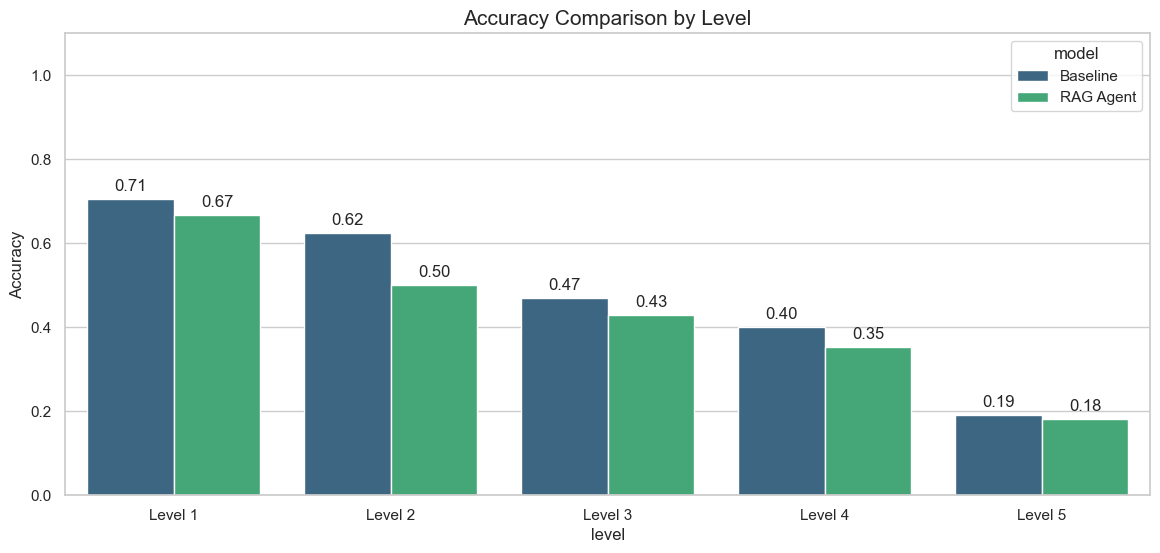

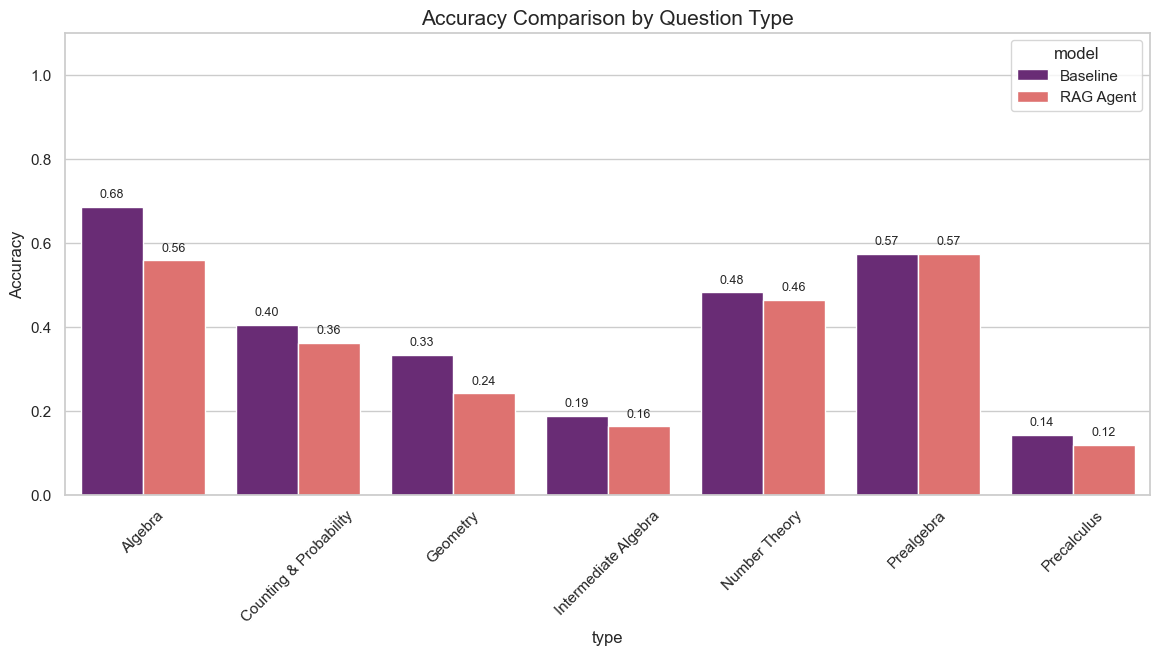

### Overall Performance Comparison ###
           Accuracy  Total
model                     
Baseline      0.442    500
RAG Agent     0.390    500

RAG Agent improved performance by -5.20%p compared to Baseline.


In [21]:
compare_evaluation_results("RAG_500.json", "baseline_500.json")